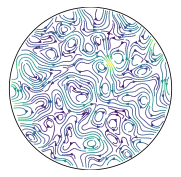

In [48]:
#generate the image for active turbulence in circular confinement.
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter
%config InlineBackend.figure_formats = ['svg']
import matplotlib
matplotlib.pyplot.rc('text', usetex=True)

# Grid settings
n = 250
x = np.linspace(-1, 1, n)
y = np.linspace(-1, 1, n)
X, Y = np.meshgrid(x, y)

# Define a circular mask (circular confinement)
mask = X**2 + Y**2 <= 1

# Generate a random stream function and smooth it to mimic turbulent structures
psi = np.random.randn(n, n)
psi = gaussian_filter(psi, sigma=10) # change the sigma parameter for different 
# scales of turbulent looking images, I chose: 10, 40, 70

# Optional: Set values outside the circle to NaN to avoid edge artifacts
psi[~mask] = np.nan

# Compute gradients of the stream function
# In a stream function formulation for incompressible 2D flow:
#   u = d(psi)/dy  and  v = -d(psi)/dx
dpsi_dy, dpsi_dx = np.gradient(psi, y, x)
u = dpsi_dy
v = -dpsi_dx

# Mask the velocity field outside the circular domain
u[~mask] = np.nan
v[~mask] = np.nan

# Create the plot using streamplot
plt.figure(figsize=(3,3))
strm = plt.streamplot(X, Y, u, v, density=2.5, color=np.sqrt(u**2+v**2),
                      cmap='viridis', linewidth=0.8, arrowsize=0.5)

# Plot the circular boundary
theta = np.linspace(0, 2*np.pi, 360)
plt.plot(np.cos(theta), np.sin(theta), color='black', linewidth=0.8)

plt.xlim([-1.05, 1.05])
plt.ylim([-1.05, 1.05])
plt.axis('equal')
plt.axis('off')
#plt.title('Active Turbulence in Circular Confinement', fontsize=16)
#plt.savefig('schematic1.png', dpi=1000)
plt.show()